In [4]:
import pandas as pd
import numpy as np

df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v4.csv',index_col = 0,encoding='latin-1')
df_env_short = df_env.iloc[:,np.append(range(0,28), range(56,61))]
df_env_short = df_env_short.drop(['TKN_pct'], axis=1)
df_env_short.columns

Index(['mean_GWC', 'K_mg_per_kg', 'SO4.S_mg_per_kg', 'B_mg_per_kg',
       'Zn_mg_per_kg', 'Mn_mg_per_kg', 'Cu_mg_per_kg', 'Fe_mg_per_kg',
       'Ca_Meq_per_100_g', 'Mg_Meq_per_100_g', 'Na_Meq_per_100_g',
       'Total_Bases_Meq_per_100_g', 'CEC_Meq_per_100_g', 'Total_Sulfur_pct',
       'Total_Nitrogen_pct', 'Total_Carbon_pct', 'C_to_N_ratio',
       'NO3.N_mg_per_g_of_soil_mean', 'NH4.N_mg_per_g_of_soil_mean',
       'P_Bicarb_mg_per_g_of_soil_mean', 'pH',
       'B.glucosidase_ug_pNP_per_g_per_hour',
       'Respiration_96_h_ug_CO2.C_per_g_soil_per_day',
       'Respiration_24_h_ug_CO2.C_per_g_soil_per_day', 'Sand_pct', 'Silt_pct',
       'Clay_pct', 'Lat', 'Long', 'Elev.m', 'Soil.Temperature.C',
       'VolWaterContent.m3.m3'],
      dtype='object')

In [5]:
df_env_short['Respiration_24_h_ug_CO2.C_per_g_soil_per_day'] = np.log10(df_env_short['Respiration_24_h_ug_CO2.C_per_g_soil_per_day']+1)
df_env_short['Total_Carbon_pct'] = np.log10(df_env_short['Total_Carbon_pct']+1)
df_env_short['Total_Nitrogen_pct'] = np.log10(df_env_short['Total_Nitrogen_pct']+1)
df_env_short['Total_Sulfur_pct'] = np.log10(df_env_short['Total_Sulfur_pct']+1)
df_env_short['Mn_mg_per_kg']= np.log10(df_env_short['Mn_mg_per_kg']+1)

In [6]:
df_env_short['Depth'] = [x[5:8] for x in df_env_short.index.values]
df_env_short.loc[df_env_short['Depth']=='TOP', 'Depth'] = 'Surface'
df_env_short.loc[df_env_short['Depth']=='BTM', 'Depth'] = 'Subsoil'

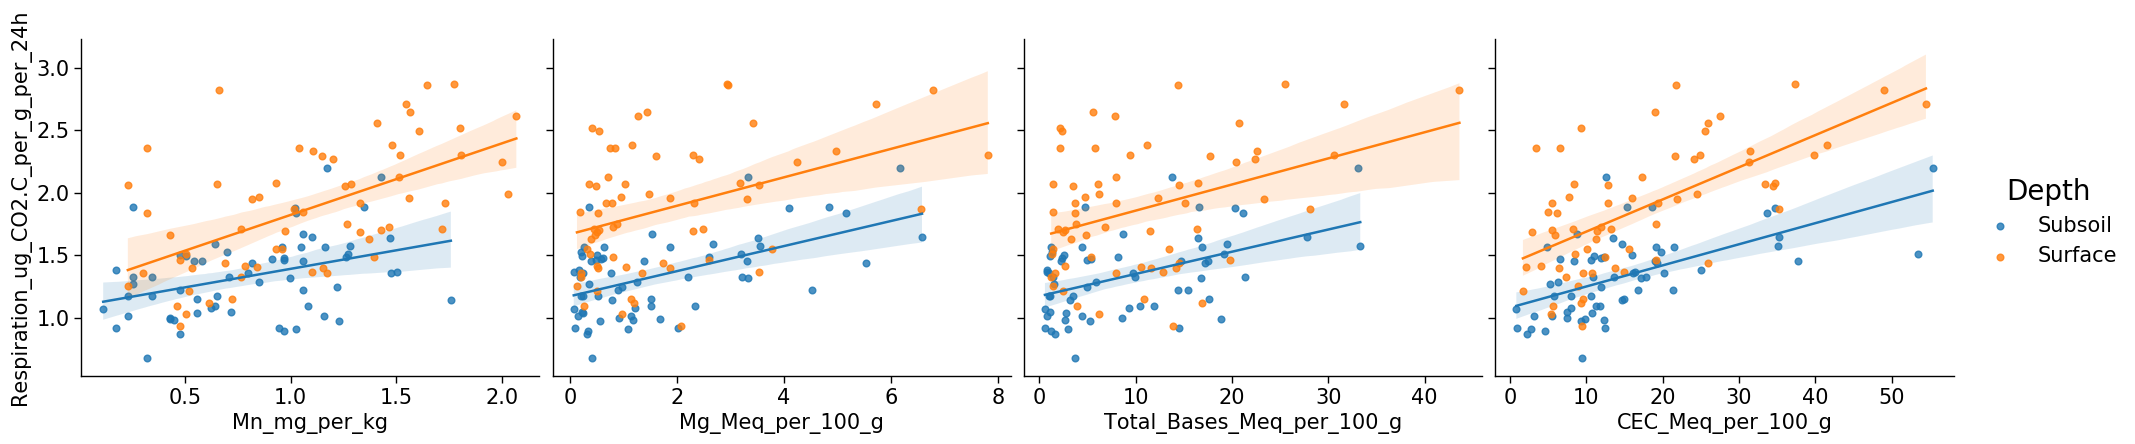

In [7]:
import seaborn as sns
sns.set_context("paper", rc={'axes.labelsize': 15,'axes.titlesize': 15,'xtick.labelsize': 15,
 'ytick.labelsize': 15,'legend.fontsize': 15, 'legend.title_fontsize': 20,})
ax = sns.pairplot(df_env_short, y_vars=["Respiration_24_h_ug_CO2.C_per_g_soil_per_day"], x_vars=["Mn_mg_per_kg", "Mg_Meq_per_100_g", "Total_Bases_Meq_per_100_g","CEC_Meq_per_100_g"],
             height=5, aspect=1, kind="reg", hue='Depth')
ax.set(ylabel='Respiration_ug_CO2.C_per_g_per_24h')

In [7]:
ax.savefig('1000s_biogeoc_respir_cor_1.pdf',format='pdf')

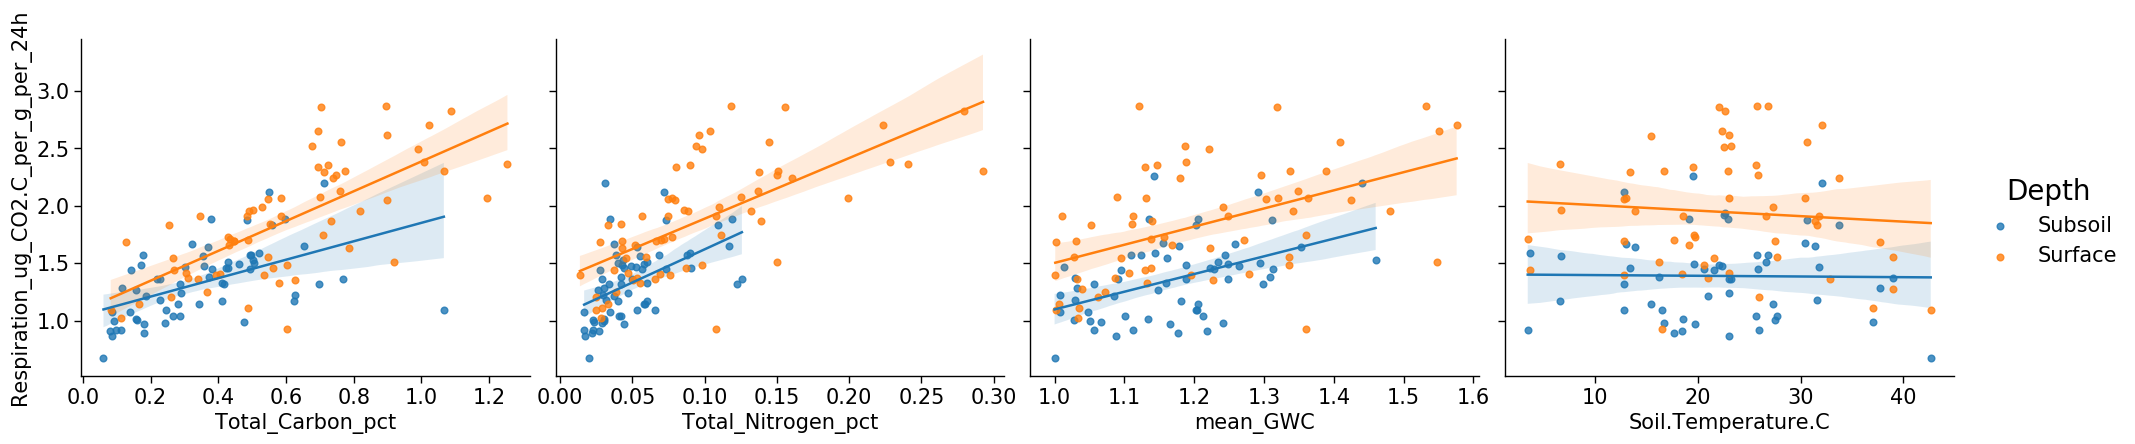

In [8]:
ax=sns.pairplot(df_env_short, y_vars=["Respiration_24_h_ug_CO2.C_per_g_soil_per_day"], x_vars=["Total_Carbon_pct", "Total_Nitrogen_pct", "mean_GWC","Soil.Temperature.C"],
             height=5, aspect=1, kind="reg", hue='Depth')
ax.set(ylabel='Respiration_ug_CO2.C_per_g_per_24h')

In [9]:
ax.savefig('1000s_biogeoc_respir_cor_2.pdf',format='pdf')

In [12]:
from scipy import stats
def calc_r2_p(var_1):
    print(var_1)
    print("Surface Soil:")
    df_t = pd.DataFrame({'x': df_env_short.loc[df_env_short.Depth=='Surface', var_1],
                      'y': df_env_short.loc[df_env_short.Depth=='Surface', 'Respiration_24_h_ug_CO2.C_per_g_soil_per_day']})
    df_t=df_t.dropna()
    slope_t, intercept_t, r_value_t, p_value_t, std_err_t = stats.linregress(df_t.x,df_t.y)
    print(f"y = {slope_t:.3f}*x+{intercept_t:.3f}, R-square: {r_value_t**2:.3f}, p_value: {p_value_t:.6f}")
    print("Subsoil:")
    df_b = pd.DataFrame({'x': df_env_short.loc[df_env_short.Depth=='Subsoil', var_1],
                      'y': df_env_short.loc[df_env_short.Depth=='Subsoil', 'Respiration_24_h_ug_CO2.C_per_g_soil_per_day']})
    df_b=df_b.dropna()
    slope_b, intercept_b, r_value_b, p_value_b, std_err_b = stats.linregress(df_b.x, df_b.y)
    print(f"y = {slope_b:.3f}*x+{intercept_b:.3f}, R-square: {r_value_b**2:.3f}, p_value: {p_value_b:.6f}")

In [13]:
calc_r2_p('Total_Carbon_pct')

Total_Carbon_pct
Surface Soil:
y = 1.298*x+1.089, R-square: 0.487, p_value: 0.000000
Subsoil:
y = 0.803*x+1.049, R-square: 0.268, p_value: 0.000016


In [14]:
calc_r2_p('Total_Nitrogen_pct')

Total_Nitrogen_pct
Surface Soil:
y = 5.277*x+1.361, R-square: 0.439, p_value: 0.000000
Subsoil:
y = 5.773*x+1.044, R-square: 0.248, p_value: 0.000039


In [15]:
calc_r2_p('Mn_mg_per_kg')

Mn_mg_per_kg
Surface Soil:
y = 0.573*x+1.248, R-square: 0.324, p_value: 0.000001
Subsoil:
y = 0.297*x+1.093, R-square: 0.142, p_value: 0.002502


In [16]:
calc_r2_p("Soil.Temperature.C")

Soil.Temperature.C
Surface Soil:
y = -0.005*x+2.054, R-square: 0.007, p_value: 0.545038
Subsoil:
y = -0.001*x+1.403, R-square: 0.000, p_value: 0.919342


In [17]:
calc_r2_p('mean_GWC')

mean_GWC
Surface Soil:
y = 1.579*x+-0.076, R-square: 0.246, p_value: 0.000041
Subsoil:
y = 1.541*x+-0.442, R-square: 0.225, p_value: 0.000129


In [18]:
calc_r2_p("CEC_Meq_per_100_g")

CEC_Meq_per_100_g
Surface Soil:
y = 0.026*x+1.430, R-square: 0.405, p_value: 0.000000
Subsoil:
y = 0.017*x+1.079, R-square: 0.354, p_value: 0.000000


In [19]:
calc_r2_p("Total_Bases_Meq_per_100_g")

Total_Bases_Meq_per_100_g
Surface Soil:
y = 0.021*x+1.646, R-square: 0.146, p_value: 0.001806
Subsoil:
y = 0.018*x+1.171, R-square: 0.227, p_value: 0.000090


In [20]:
calc_r2_p("Mg_Meq_per_100_g")

Mg_Meq_per_100_g
Surface Soil:
y = 0.114*x+1.667, R-square: 0.160, p_value: 0.001044
Subsoil:
y = 0.100*x+1.171, R-square: 0.287, p_value: 0.000007
